In [1]:
import numpy as np
import os
import unyt

In [2]:
def gaussian(x, mu, sig):
    return np.exp(-np.power(x - mu, 2.) / (2 * np.power(sig, 2.)))

def CalGradient(quan,xdelta,coordinate):
    # only work for periodic boundary condition!
    dqdx = ( np.roll(quan,-1) - np.roll(quan,1) ) / (2. * xdelta)
    return dqdx

def CalInterFaceFluxGLF(flux_L: float, flux_R: float, q_L: float, q_R: float, cmax: float) -> float:
    # Global Lax Friedrich function
    # F_(l+1/2) = 0.5*(F_L+F_R)+0.5*cmax*(q_L-q_R)    
    InterFaceFlux = 0.5 * (flux_L + flux_R)
    # apply artifical diffusion +0.5*cmax*(q_L-q_R)
    InterFaceFlux += 0.5*cmax*(q_L-q_R)
    return InterFaceFlux
    
def CalFluxLimiter(rlim, limiter='minmod'):
    if limiter=='minmod':
        firststep = np.minimum(np.ones(len(rlim)), rlim)
        philim = np.maximum(np.zeros(len(rlim)), firststep)
    return philim

def extrapolateToFace(fluxarray: float, xb:float, fgrad:float, order=1):
    #numpy roll Rroll, put the right value to this cell
    Lroll = 1
    Rroll = -1
    if order == 0:
        flux_R = fluxarray
        flux_L = np.roll(fluxarray,Lroll)
    elif order == 1:    
        xdhalf = 0.5*(xb[1:]-xb[:-1])
        flux_R = fluxarray - fgrad * xdhalf
        # the following is correct in the first order case
        flux_L = np.roll(fluxarray+fgrad*xdhalf , Lroll) 
    return flux_L, flux_R

def GetFQ(rho,u,p,gamma):
    Fmass = rho*u
    qmass = rho
    #Fmom  = rho * u**2 * u/np.absolute(u) 
    Fmom  = rho * u**2
    Fmom[np.logical_or(u==0.0,np.isnan(u))] = 0.0 * rho[0] * u[0]**2
    Fmom += p
    qmom  = rho * u
    FEn   = u * (gamma * p / (gamma - 1.0) + 0.5 * rho * u**2)
    qEn   = p/(gamma-1.0) + rho * u**2*0.5
    return Fmass, qmass, Fmom, qmom, FEn, qEn 


def CalFluxFromLR(rho_L,rho_R,u_L,u_R,p_L,p_R,gamma,cmax):
    Fmass_L, qmass_L, Fmom_L, qmom_L, FEn_L, qEn_L  = GetFQ(rho_L, u_L, p_L, gamma)
    Fmass_R, qmass_R, Fmom_R, qmom_R, FEn_R, qEn_R  = GetFQ(rho_R, u_R, p_R, gamma)

    Mass_flux = CalInterFaceFluxGLF(Fmass_L, Fmass_R, qmass_L, qmass_R, cmax)
    Mom_flux = CalInterFaceFluxGLF(Fmom_L, Fmom_R, qmom_L, qmom_R, cmax)
    Energy_flux = CalInterFaceFluxGLF(FEn_L, FEn_R, qEn_L, qEn_R, cmax)   
    return Mass_flux, Mom_flux, Energy_flux


def ApplyFluxLimiter(q,flux_1,flux_0):
    #numpy roll Rroll, put the right value to this cell
    Lroll = 1
    Rroll = -1
    bottom = np.roll(q,Rroll)-q
    rlim = (q-np.roll(q,Lroll))/bottom
    rlim[np.logical_or(bottom==0,np.isnan(bottom))] = 0.0
    philim = CalFluxLimiter(rlim)
    return flux_0 - philim * (flux_0-flux_1)

In [3]:
# set up the underlying mesh for fluid
class Mesh:
    def __init__(self, boxsize: float, nogrid: int, coordinate: str, area = 1.0 * unyt.pc**2):
        self.nogrid = nogrid
        if nogrid < 1:
            print('nogrid has to be bigger than 1')
            exit()
        self.coordinate = coordinate
        self.boxsize = boxsize
        # boundary points of the mesh
        # note that we use first (0) and final (nogrid+1) cells as ghost cells
        # to set boundary conditions
        dx = boxsize/nogrid
        self.xbound = np.linspace(-dx,boxsize+dx,nogrid+3)
        # mesh coordinate is the midpoint of xbound
        self.xmesh = 0.5 * (self.xbound[1:]+self.xbound[:-1])
        # mesh size
        self.xdelta = self.xbound[1:] - self.xbound[:-1]
        self.oneoverdx = 1.0/self.xdelta
        if coordinate == 'cartesian':
            self.area = np.ones(nogrid+2) * area
            self.vol = (self.xbound[1:] - self.xbound[:-1]) * self.area
        elif coordinate == 'spherical':
            self.area = (self.xbound[1:]**2 - self.xbound[:-1]**2)*4.0*np.pi
            self.vol = (self.xbound[1:]**3 - self.xbound[:-1]**3)*4.0*np.pi/3.0
        else:
            print('coordinate unknown')
            
        if np.any(self.vol == 0.0) or np.any(np.isnan(self.vol)):
            print('vol vanished')
            exit()

            

In [4]:
# set up the equation of state
class EOS:
    def __init__(self,EOStype: str,gamma=5./3.):
        self.EOStype = EOStype
        self.gamma = gamma
        if gamma==1.0:
            print('gamma cannot be equal to 1')
            exit()
        if ((self.EOStype != 'polytropic') and (self.EOStype != 'isothermal')):
            print("EOS not recognized: only polytropic or isothermal")
        
    def CalPressure(self,rho,temp,mu):
        pressure = rho / (mu * unyt.mp) * unyt.kb * temp
        return pressure
    
    def CalEnergyDensity(self,pressure):
        energydensity = pressure / (self.gamma-1.0)
        return energydensity
    
    def CalSoundSpeed(self,pressure,rho):
        soundspeed = np.sqrt(self.gamma * pressure / rho)
        return soundspeed
        
    def PressuretoDensity(self,Pressure):
        if self.EOStype == 'polytropic':
            Density = Pressure**(1.0/self.gamma)
            return Density
        elif self.EOStype == 'isothermal':
            Density = Pressure            
            return Density
            
    def DensitytoPressure(self,Density):
        if self.EOStype == 'polytropic':
            Pressure = Density**self.gamma
            return Pressure
        elif self.EOStype == 'isothermal':
            Pressure = Density
            return Pressure  

In [5]:
# set up fluid properties

class Fluid():
    # import mesh and EOS information into Fluid
    def __init__(self, mesh: Mesh, eos: EOS, tini: float, ftype: str):
        Fluid.mesh = mesh
        Fluid.eos = eos
        Fluid.time = tini 
        Fluid.ftype = ftype
    
    def SetPressure(self):
        self.p = self.eos.CalPressure(self.rho,self.temp,self.mu)
        
    def SetEnergyDensity(self):
        self.eth = self.eos.CalEnergyDensity(self.p)
        
    def SetSoundSpeed(self):
        self.cs = self.eos.CalSoundSpeed(self.p,self.rho)
        
    def SetPrimitive(self, verbose=0):
        vol = self.mesh.vol
        self.rho = self.Mass / vol
        self.u = self.Mom / self.Mass
        self.p = (self.Energy/vol-0.5*self.rho*self.u**2)*(self.eos.gamma-1.0)
        self.rho[np.logical_or(self.rho<0.0, np.isnan(self.rho))] = 0.0
        self.p[np.logical_or(self.p<0.0, np.isnan(self.p))] = 0.0            
        if verbose == 1:
            print('self.rho',self.rho)
            print('self.u',self.u)
            print('self.p',self.p)            
        
        
    def SetConserved(self, verbose=0):
        vol = self.mesh.vol
        self.Mass = self.rho * vol
        self.Mom = self.rho * self.u * vol
        self.Energy = (0.5*self.rho*self.u**2 + self.p/(self.eos.gamma-1.0))*vol
        self.Mass[np.logical_or(self.Mass<0.0, np.isnan(self.Mass))] = 0.0
        self.Energy[np.logical_or(self.Energy<0.0, np.isnan(self.Energy))] = 0.0
        if verbose == 1:
            print('self.Mass',self.Mass)
            print('self.Mom',self.Mom)
            print('self.Energy',self.Energy)
        
        
    def SetGradient(self):
        xdelta = self.mesh.xdelta
        coordinate = self.mesh.coordinate
        self.rho.grad = CalGradient(self.rho, xdelta, coordinate)
        self.u.grad   = CalGradient(self.u, xdelta, coordinate)
        self.p.grad   = CalGradient(self.p, xdelta, coordinate)
        
    def SetConservedDensityFlux(self):
        gamma = self.eos.gamma
        self.Mass.F, self.Mass.q, self.Mom.F, self.Mom.q, self.Energy.F, self.Energy.q = GetFQ(self.rho,self.u,self.p,self.eos.gamma)
        
    def SetFaceLR(self,order=0):
        #numpy roll Rroll, put the right value to this cell
        Lroll = 1
        Rroll = -1
        if order == 0 or order == 1:
            self.rho.R = self.rho
            self.rho.L = np.roll(self.rho, Lroll)
            self.u.R = self.u
            self.u.L = np.roll(self.u, Lroll)
            self.p.R = self.p
            self.p.L = np.roll(self.p, Lroll)
            if order == 1:
                self.SetGradient()
                self.rho.R.first, self.rho.L.first = extrapolateToFace(self.rho, self.mesh.xbound, self.rho.grad, order=1)
                self.u.R.first, self.u.L.first = extrapolateToFace(self.u, self.mesh.xbound, self.u.grad, order=1)
                self.p.R.first, self.p.L.first = extrapolateToFace(self.p, self.mesh.xbound, self.p.grad, order=1)
        else:
            print('order unknown')
        
        
    
    def SetInitFluid(self, rhoini: float, uini: float, tempini: float, verbose=0):  
        nogrid = self.mesh.nogrid
        if self.ftype=='uniform':
            self.rho = np.ones(nogrid+2) * rhoini
            self.u = np.ones(nogrid+2) * uini
            self.temp = np.ones(nogrid+2) * tempini
            # mean molecular weight
            self.mu = np.ones(nogrid+2) * 1.28 # for primordial neutral gas
        elif self.ftype=='half':
            self.rho = np.ones(nogrid+2) * rhoini
            self.u = np.ones(nogrid+2) * uini
            self.temp = np.ones(nogrid+2) * tempini
            self.rho[np.logical_or(self.mesh.xmesh<0.25*self.mesh.boxsize, self.mesh.xmesh>0.75*self.mesh.boxsize)] *= 0.5
            # mean molecular weight
            self.mu = np.ones(nogrid+2) * 1.28 # for primordial neutral gas  
        elif self.ftype=='gaussian':
            self.rho = (1.0+gaussian(self.mesh.xmesh, 0.5*self.mesh.boxsize, 0.1*self.mesh.boxsize))* rhoini
            self.u = np.ones(nogrid+2) * uini
            self.temp = np.ones(nogrid+2) * tempini
            # mean molecular weight
            self.mu = np.ones(nogrid+2) * 1.28 # for primordial neutral gas  
        elif self.ftype=='sodshock':
            self.mu = np.ones(nogrid+2) * 1.28 # for primordial neutral gas    
            self.rho = np.ones(nogrid+2) * rhoini
            self.u = np.ones(nogrid+2) * uini
            self.temp = np.ones(nogrid+2) * tempini
            self.rho[self.mesh.xmesh>0.5*self.mesh.boxsize] *= 0.1
            self.temp[self.mesh.xmesh>0.5*self.mesh.boxsize] *= 0.1/0.125
            # mean molecular weight
            self.mu = np.ones(nogrid+2) * 1.28 # for primordial neutral gas            
        else:
            print('ftype unknown')
        self.SetPressure()
        if verbose == 1:
            print('self.rho',self.rho)
            print('self.u',self.u)
            print('self.p',self.p)
            
 

        
        
    def SetFluxOnFace(self,order=0):
        #numpy roll Rroll, put the right value to this cell
        Lroll = 1
        Rroll = -1
        Mass_flux_0, Mom_flux_0, Energy_flux_0 = CalFluxFromLR(self.rho.L,self.rho.R,
                                                               self.u.L,self.u.R,
                                                               self.p.L,self.p.R,
                                                               self.eos.gamma,self.cmax)
        if order==0:
            self.Mass.flux, self.Mom.flux, self.Energy.flux = Mass_flux_0, Mom_flux_0, Energy_flux_0
        elif order==1:
            Mass_flux_1, Mom_flux_1, Energy_flux_1 = CalFluxFromLR(self.rho.L.first, self.rho.R.first,
                                                                    self.u.L.first, self.u.R.first,
                                                                    self.p.L.first, self.p.R.first,
                                                                    self.eos.gamma, self.cmax)
            self.SetConservedDensityFlux()
            self.Mass.flux = ApplyFluxLimiter(self.Mass.q,Mass_flux_1,Mass_flux_0)
            self.Mom.flux  = ApplyFluxLimiter(self.Mom.q,Mom_flux_1,Mom_flux_0)
            self.Energy.flux  = ApplyFluxLimiter(self.Energy.q,Energy_flux_1,Energy_flux_0)
            
        else:
            print('order unknown')

        
    def SetInterFaceFlux(self,method='Rusanov',verbose=0, order=0):
        if method=='GLF' or method=='Rusanov':
            #numpy roll Rroll, put the right value to this cell
            Lroll = 1
            Rroll = -1
            if method=='GLF':
                # Global Lax Friedrich scheme
                # F_(l+1/2) = 0.5*(F_L+F_R)+0.5*cmax*(q_L-q_R)  
                # simple to implement but very diffusive
                # calculate cmax
                self.cmax = self.mesh.xdelta/np.amin(self.dt)
            elif method=='Rusanov':
                # Local Lax Friedrich schem
                # F_(l+1/2) = 0.5*(F_L+F_R)+0.5*cmax*(q_L-q_R)  
                # simple to implement but less diffusive
                self.cmax = np.maximum(self.vsignal, np.roll(self.vsignal,Lroll))
            
            self.SetFaceLR(order=order)
            self.SetFluxOnFace(order=order)
        else:
            print('Interface flux method unknown')
            exit()
        if (verbose==1):
            print('self.Mass.flux',self.Mass.flux)
            print('self.Mom.flux',self.Mom.flux)
            print('self.Energy.flux',self.Energy.flux)
            
            
    def AddFluxes(self, dt: float):
        #numpy roll Rroll, put the right value to this cell
        Lroll = 1
        Rroll = -1
        # Add the interface fluxes to the cells:
        area = self.mesh.area
        vol = self.mesh.vol
        self.Mass += (self.Mass.flux*area - np.roll(self.Mass.flux*area,Rroll))*dt
        self.Mom  += (self.Mom.flux*area - np.roll(self.Mom.flux*area,Rroll))*dt
        self.Energy  += (self.Energy.flux*area - np.roll(self.Energy.flux*area,Rroll))*dt
        self.time += dt
        
    
    def GetTimeStep(self, CFL=0.1, vsmin = 0.001*unyt.km/unyt.s):
        self.SetSoundSpeed()
        vsignal = np.absolute(self.u) + self.cs
        #if np.any(vsignal==0) or np.any(np.isnan(vsignal)):
        #    print('vsignal vanished')    
        #else:
        vsignal[np.logical_or(vsignal==0.0,np.isnan(vsignal))] = vsmin
        dx_c = self.mesh.xdelta / vsignal
        self.dt =  CFL * np.amin(dx_c)
        self.vsignal = vsignal
        dt = np.amin(self.dt)
        #print('vsignal', vsignal)
        return dt
     
    
    def SetBoundary(self,btype:str):
        if btype == 'Periodic':
            self.rho[0] = self.rho[-2]
            self.u[0] = self.u[-2]
            self.p[0] = self.p[-2]
            self.rho[-1] = self.rho[1]
            self.u[-1] = self.u[1]
            self.p[-1] = self.p[1]            
        else:
            print('Boundary condition unknown')           


\begin{align}
\left\{\begin{matrix}
 Continuity: & \frac{\partial \rho}{\partial t}+\nabla\cdot\left ( \rho {\bf u} \right )&=S_\rho,\\\\ 
 Momentum: & \frac{\partial \rho {\bf u}}{\partial t}+\nabla\cdot\left ( \rho {\bf u}{\bf u}^T \right )+\nabla p-{\bf f}&=S_{\bf p},\\\\ 
 Energy: & \frac{\partial e}{\partial t}+\nabla\cdot\left [ {\bf u}\left ( e+p \right ) \right ]&=S_{e}
\end{matrix}\right.
\end{align}
with
\begin{align}
e=\frac{p}{\gamma-1} + \frac{1}{2}\rho u^2
\end{align}


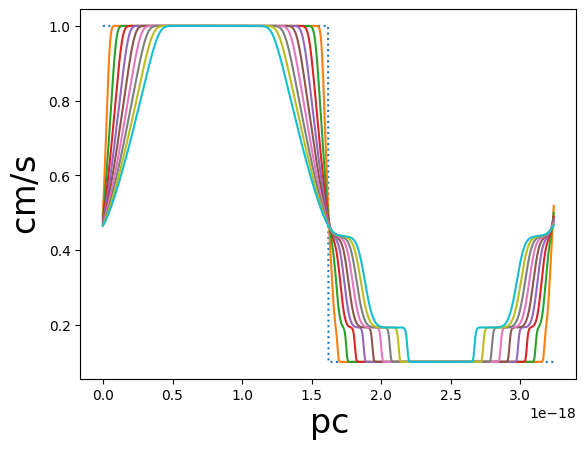

In [13]:
import matplotlib.pyplot as plt
params_sodshock = {
    'coordinate':'cartesian', #
    'EOStype':'polytropic', #type of equation of state (EOS): polytropic or isothermal
    'gamma':5./3., # for polytropic, the polytropic index
    'boxsize':10.0*unyt.cm, # length of the simulation domain
    'timesim':1.0*unyt.s, # total simulation time
    'ngrid':1000, # number of grid to discretize
    'CFL':0.1, # CFL condition for time-step
    'ftype':'sodshock', # initial fluid distribution: uniform, half, gaussian, sodshock
    'tini': 0.*unyt.yr, # initial time
    'rhoini':  1.0 * unyt.g/unyt.cm**3, 
    'vini': 0.0 * unyt.cm/unyt.s,
    'tempini': 1.0 * unyt.g / unyt.cm / unyt.s**2 * (1.28 * unyt.mp) / unyt.kb / (1.0 * unyt.g/unyt.cm**3),
    'boundcond':'Periodic',
    'verbose':0, # speak out details?
    'fixtemp':1, #fix the value of temperature
    'fixvel':1   #fix the value of velocity
}


params_half = {
    'coordinate':'cartesian', #
    'EOStype':'polytropic', #type of equation of state (EOS): polytropic or isothermal
    'gamma':1.4, # for polytropic, the polytropic index
    'boxsize':1.0*unyt.pc, # length of the simulation domain
    'timesim':1.0*unyt.Myr, # total simulation time
    'ngrid':1000, # number of grid to discretize
    'CFL':0.1, # CFL condition for time-step
    'ftype':'gaussian', # initial fluid distribution: uniform, half, gaussian, sodshock
    'tini': 0.*unyt.yr, # initial time
    'rhoini': 1.0 * unyt.mp/ unyt.cm**3, 
    'vini': 1.0 * unyt.km/unyt.s,
    'tempini': 0.1 * unyt.K,
    'boundcond':'Periodic',
    'verbose':0, # speak out details?
    'fixtemp':1, #fix the value of temperature
    'fixvel':1   #fix the value of velocity
}


params = params_sodshock

cave = Mesh(params['boxsize'],params['ngrid'],params['coordinate'])
peos = EOS(params['EOStype'],params['gamma'])
water = Fluid(cave,peos,params['tini'],params['ftype'])
water.SetInitFluid(params['rhoini'],params['vini'],params['tempini'],params['verbose'])
water.SetConserved(verbose=params['verbose'])

#plt.plot(water.mesh.xmesh, water.rho.in_cgs()*water.u.in_cgs())
timecount = 0.0 *unyt.Myr
plt.plot(water.mesh.xmesh.to('pc'), water.rho.in_cgs(),ls='dotted')
while water.time < params['timesim']:
    dt = water.GetTimeStep()
    water.SetBoundary(params['boundcond'])
    water.SetConserved(verbose=params['verbose'])
    water.SetInterFaceFlux(verbose=params['verbose'],order=0)
    water.AddFluxes(dt)
    water.SetPrimitive(verbose=params['verbose'])
    #print('dt',dt)
    timecount += dt
    if timecount > 0.1 *params['timesim']:
        plt.plot(water.mesh.xmesh.to('pc'), water.rho.in_cgs())
        #plt.show()
        timecount *= 0.0
    #plt.plot(water.mesh.xmesh.to('pc'), water.rho.in_cgs())
        
plt.xlabel(r'$'+water.mesh.xmesh.to('pc').units.latex_repr+'$',fontsize=24)
plt.ylabel(r'$'+water.u.in_cgs().units.latex_repr+'$',fontsize=24)
plt.show()

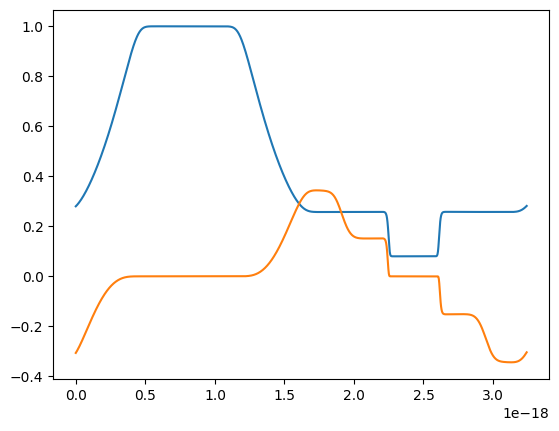

In [14]:
plt.plot(water.mesh.xmesh.to('pc'), water.p.in_cgs())
plt.plot(water.mesh.xmesh.to('pc'), water.rho.in_cgs()*water.u.in_cgs()**3)

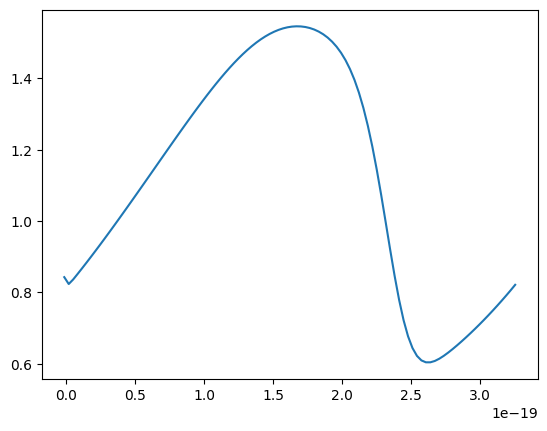

In [8]:
water.SetInterFaceFlux(verbose=params['verbose'],order=0)
plt.plot(water.mesh.xmesh.to('pc'), water.Mom.flux.in_cgs())